#  Amélioration du modèle 

## Objectif
On va essayé ici d'améliorer le modèle d'élasticité en intégrant de nouvelles variables car le modèle actuel calcule l'élasticité avec seulement le prix :
- `note_client` : satisfaction client
- `frais_livraison` : coût de livraison
- `ratio_livraison` : rapport frais_livraison / prix total

## Modèle utilisé
On remplace la régression linéaire par un **Random Forest**  
qui peut capturer des relations complexes entre les variables.

## Questions auxquelles on répond
1. La note client influence-t-elle la sensibilité au prix ?
2. Les frais de livraison jouent-ils un rôle dans les ventes ?
3. Quelles variables sont les plus importantes pour prédire les ventes ?
4. Le nouveau modèle améliore-t-il les prédictions ?

## 1. Chargement et préparation des données

In [2]:
# ============================================================
# IMPORTS ET CHARGEMENT DES DONNÉES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

np.random.seed(42)

# Chargement des données nettoyées
df = pd.read_csv('../data/df_clean.csv')

print(" Données chargées")
print(f"   - Lignes     : {df.shape[0]:,}")
print(f"   - Colonnes   : {df.columns.tolist()}")
print(f"\n=== Valeurs manquantes ===")
print(df.isnull().sum())

 Données chargées
   - Lignes     : 108,660
   - Colonnes   : ['commande_id', 'produit_id', 'prix', 'frais_livraison', 'note_client', 'categorie']

=== Valeurs manquantes ===
commande_id          0
produit_id           0
prix                 0
frais_livraison      0
note_client        815
categorie            0
dtype: int64


## 2. Préparation des features

On crée les nouvelles variables et on gère les valeurs manquantes. Pour les 815 notes manquantes, on pourrait imputé par la médiane car 815/108660 soit 0,75% (peu de données manquante) et de plus présence d'assymétrie. Pour plus de robustesse on choisi ici l'imputation multiple.
Pour ce faire, on va utiliser prix, frais_livraison, categorie pour prédire la note la plus probable.

In [3]:
# ============================================================
# PRÉPARATION DES FEATURES AVEC IMPUTATION MICE
# ============================================================

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

df_model = df.copy()

print(f"Notes manquantes avant imputation : {df_model['note_client'].isna().sum()}")

# --- Encodage de la catégorie en numérique ---
# MICE ne peut travailler qu'avec des nombres
# On encode chaque catégorie par son prix médian
df_model['categorie_encoded'] = df_model.groupby('categorie')['prix'].transform('median')

# --- Préparation des données pour MICE ---
# On utilise prix, frais_livraison et categorie_encoded
# pour prédire note_client
colonnes_mice = ['prix', 'frais_livraison', 'categorie_encoded', 'note_client']
df_mice = df_model[colonnes_mice].copy()

# --- Application de MICE ---
# max_iter : nombre d'itérations (10 est standard)
# random_state : pour la reproductibilité
imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=10, random_state=42),
    max_iter=10,
    random_state=42,
    verbose=1  # Affiche la progression
)

df_imputed = imputer.fit_transform(df_mice)

# Récupérer uniquement la colonne note_client imputée
df_model['note_client'] = df_imputed[:, 3]  # note_client est la 4ème colonne

# Arrondir les notes entre 1 et 5
df_model['note_client'] = df_model['note_client'].clip(1, 5).round(1)

print(f"\n Notes manquantes après MICE : {df_model['note_client'].isna().sum()}")
print(f"\n=== Distribution des notes après imputation ===")
print(df_model['note_client'].describe().round(2))

Notes manquantes avant imputation : 815
[IterativeImputer] Completing matrix with shape (108660, 4)
[IterativeImputer] Change: 3.0837034633038156, scaled tolerance: 6.735 
[IterativeImputer] Early stopping criterion reached.

 Notes manquantes après MICE : 0

=== Distribution des notes après imputation ===
count    108660.00
mean          4.08
std           1.34
min           1.00
25%           4.00
50%           5.00
75%           5.00
max           5.00
Name: note_client, dtype: float64


> **Choix d'imputation : MICE (Multiple Imputation by Chained Equations)**
> - Méthode choisie pour sa précision vs la simple médiane
> - Utilise prix, frais_livraison et catégorie pour prédire les notes manquantes
> - Convergence rapide (early stopping) car seulement 0.75% de données manquantes
> - Distribution préservée : moyenne 4.08 vs 4.09 avant imputation 

## 3. Création des nouvelles variables

On crée les features supplémentaires pour  enrichir notre modèle.

In [4]:
# ============================================================
# CRÉATION DES NOUVELLES VARIABLES
# ============================================================

# Ratio frais de livraison / prix
# Plus ce ratio est élevé, plus la livraison pèse dans l'achat
df_model['ratio_livraison'] = df_model['frais_livraison'] / df_model['prix']

# Prix total ressenti par le client (prix + livraison)
df_model['prix_total'] = df_model['prix'] + df_model['frais_livraison']

# Segment de note client (1-2 : mauvais, 3 : moyen, 4-5 : bon)
df_model['segment_note'] = pd.cut(
    df_model['note_client'],
    bins=[0, 2, 3, 5],
    labels=['Mauvais', 'Moyen', 'Bon']
)

print(" Nouvelles variables créées")
print(f"\n=== Aperçu des nouvelles variables ===")
print(df_model[['prix', 'frais_livraison', 'ratio_livraison', 
                 'prix_total', 'note_client', 'segment_note']].head(10))

print(f"\n=== Statistiques ===")
print(df_model[['ratio_livraison', 'prix_total', 'note_client']].describe().round(2))

 Nouvelles variables créées

=== Aperçu des nouvelles variables ===
     prix  frais_livraison  ratio_livraison  prix_total  note_client  \
0   29.99             8.72         0.290764       38.71          4.0   
1  118.70            22.76         0.191744      141.46          4.0   
2  159.90            19.22         0.120200      179.12          5.0   
3   45.00            27.20         0.604444       72.20          5.0   
4   19.90             8.72         0.438191       28.62          5.0   
5  147.90            27.36         0.184990      175.26          4.0   
6   59.99            15.17         0.252875       75.16          5.0   
7   19.90            16.05         0.806533       35.95          1.0   
8  149.99            19.77         0.131809      169.76          5.0   
9   99.00            30.53         0.308384      129.53          1.0   

  segment_note  
0          Bon  
1          Bon  
2          Bon  
3          Bon  
4          Bon  
5          Bon  
6          Bon  
7  

- On voit que le ratio_livraison médian est de 0.23, ce qui veut dire qu'en moyenne les frais de livraison représentent 23% du prix.
- Le ratio max de 26.24 (énorme) car ca veut dire que certains produits ont des frais de livraison qui représentent 26 fois le prix, ce sont probablement des produits très bon marché.
- prix_total médian : 92 R$ vs prix médian 74 R$ donc la livraison ajoute en moyenne ~18R$.

## 4. Entraînement du modèle Random Forest

On entraîne un Random Forest par catégorie pour prédire le nombre de ventes en fonction de toutes nos variables.

### Pourquoi Random Forest ?
- Il Capture les relations non-linéaires entre variables
- Il est Robuste aux outliers
- Il Fournit l'importance de chaque variable
- Pas besoin de normaliser les données

In [5]:
# ============================================================
# ENTRAÎNEMENT DU RANDOM FOREST PAR CATÉGORIE
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# Features utilisées pour le modèle
FEATURES = ['prix', 'frais_livraison', 'ratio_livraison', 
            'prix_total', 'note_client']

resultats_rf = []

# Agréger les données par produit et catégorie
df_agg = (df_model.groupby(['produit_id', 'categorie'])
                  .agg(
                      prix=('prix', 'mean'),
                      frais_livraison=('frais_livraison', 'mean'),
                      ratio_livraison=('ratio_livraison', 'mean'),
                      prix_total=('prix_total', 'mean'),
                      note_client=('note_client', 'mean'),
                      nb_ventes=('commande_id', 'count')
                  )
                  .reset_index())

print(f" Données agrégées : {df_agg.shape[0]:,} produits uniques")
print(f"\n=== Aperçu ===")
print(df_agg.head())

 Données agrégées : 31,632 produits uniques

=== Aperçu ===
                         produit_id                categorie    prix  \
0  00066f42aeeb9f3007548bb9d3f33c38               Parfumerie  101.65   
1  00088930e925c41fd95ebfe695fd2655               Automobile  129.90   
2  0009406fd7479715e4bef61dd91f2462  Literie & Salle de bain  229.00   
3  000b8f95fcb9e0096488278317764d19      Ustensiles Ménagers   58.90   
4  000d9be29b5207b54e86aa1b1ac54872        Montres & Cadeaux  199.00   

   frais_livraison  ratio_livraison  prix_total  note_client  nb_ventes  
0            18.59         0.182882      120.24          5.0          1  
1            13.93         0.107236      143.83          4.0          1  
2            13.10         0.057205      242.10          1.0          1  
3            19.60         0.332767       78.50          5.0          2  
4            19.27         0.096834      218.27          5.0          1  


31 632 produits uniques agrégés. On remarque que beaucoup de produits n'ont qu'une vente, ce qui n'est pas surprenant pour un dataset e-commerce.

## 5. Entraînement et évaluation par catégorie

Pour chaque catégorie, on va entraîner un Random Forest et on mesure sa performance avec le R².
On compare aussi avec le modèle simple (régression linéaire) pour voir si on s'améliore.

In [6]:
# ============================================================
# ENTRAÎNEMENT PAR CATÉGORIE
# ============================================================

from sklearn.linear_model import LinearRegression

resultats_rf = []

for categorie in df_agg['categorie'].unique():
    
    df_cat = df_agg[df_agg['categorie'] == categorie]
    
    # Ignorer les catégories avec moins de 30 produits
    if len(df_cat) < 30:
        continue
    
    X = df_cat[FEATURES]
    y = df_cat['nb_ventes']
    
    # Split train/test 80/20
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    # --- Modèle 1 : Régression linéaire (ancien modèle) ---
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    r2_lr = r2_score(y_test, lr.predict(X_test))
    
    # --- Modèle 2 : Random Forest (nouveau modèle) ---
    rf = RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1  # Utilise tous les CPU disponibles
    )
    rf.fit(X_train, y_train)
    r2_rf = r2_score(y_test, rf.predict(X_test))
    mae_rf = mean_absolute_error(y_test, rf.predict(X_test))
    
    # Importance des variables
    importances = dict(zip(FEATURES, rf.feature_importances_.round(3)))
    
    resultats_rf.append({
        'categorie'        : categorie,
        'nb_produits'      : len(df_cat),
        'r2_lineaire'      : round(r2_lr, 3),
        'r2_random_forest' : round(r2_rf, 3),
        'mae'              : round(mae_rf, 3),
        'amelioration'     : round(r2_rf - r2_lr, 3),
        **{f'imp_{k}': v for k, v in importances.items()}
    })

resultats_rf_df = pd.DataFrame(resultats_rf)
resultats_rf_df = resultats_rf_df.sort_values('r2_random_forest', ascending=False)

print(f" Modèles entraînés pour {len(resultats_rf_df)} catégories")
print(f"\n=== Comparaison R² moyen ===")
print(f"Régression linéaire : {resultats_rf_df['r2_lineaire'].mean():.3f}")
print(f"Random Forest       : {resultats_rf_df['r2_random_forest'].mean():.3f}")
print(f"Amélioration moyenne: +{resultats_rf_df['amelioration'].mean():.3f}")

print(f"\n=== Top 10 catégories par R² Random Forest ===")
cols = ['categorie', 'nb_produits', 'r2_lineaire', 'r2_random_forest', 'amelioration']
print(resultats_rf_df.head(10)[cols].to_string(index=False))

 Modèles entraînés pour 56 catégories

=== Comparaison R² moyen ===
Régression linéaire : -0.528
Random Forest       : -0.907
Amélioration moyenne: +-0.378

=== Top 10 catégories par R² Random Forest ===
          categorie  nb_produits  r2_lineaire  r2_random_forest  amelioration
   Électroménager 2           88        0.014             0.650         0.636
    Outils & Jardin          725       -0.016             0.549         0.564
               Bébé          890        0.008             0.501         0.493
 Mode & Accessoires          829       -0.050             0.490         0.540
         Parfumerie          857        0.000             0.453         0.453
    Mobilier Bureau          302        0.020             0.420         0.400
    Sport & Loisirs         2822        0.002             0.391         0.390
             Jouets         1373       -0.011             0.355         0.366
         Animalerie          710        0.010             0.306         0.296
Construction Mai

On observe que  le Random Forest améliore significativement certaines catégories
- Électroménager 2 : R² passe de 0.014 → 0.650 🎉
- Outils & Jardin : 0.016 → 0.549
- Bébé : 0.008 → 0.501

Mais le bémole ici est que le R² moyen est négatif (-0.907), ce qui veut dire que le modèle est mauvais en moyenne. Ceci est probablement causé par le fait que la majorité des produits ont un seule vente, il donc donc compliqué de prédire combien de fois un produit sera vendu juste avec ses caractéristiques.

La solution simple sera de prédire les ventes par tranche de prix comme dans notre modèle original, mais cette fois en ajoutant note_client et ratio_livraison comme variables supplémentaires au lieu de prédire les ventes par produit.

## 6. Correction : modèle par tranche de prix

On agrège les données par tranche de prix et catégorie pour avoir assez de signal. On ajoute note_client et ratio_livraison comme variables supplémentaires.

In [7]:
# ============================================================
# MODÈLE AMÉLIORÉ PAR TRANCHE DE PRIX
# ============================================================

resultats_rf_v2 = []

for categorie in df_model['categorie'].unique():
    
    df_cat = df_model[df_model['categorie'] == categorie].copy()
    
    # Ignorer les catégories avec moins de 100 ventes
    if len(df_cat) < 100:
        continue
    
    # Créer 10 tranches de prix
    df_cat['tranche_prix'] = pd.qcut(
        df_cat['prix'], 
        q=10, 
        duplicates='drop'
    )
    
    # Agréger par tranche
    data = (df_cat.groupby('tranche_prix', observed=True)
                  .agg(
                      prix_moyen=('prix', 'mean'),
                      note_moyenne=('note_client', 'mean'),
                      ratio_livraison_moyen=('ratio_livraison', 'mean'),
                      nb_ventes=('commande_id', 'count')
                  )
                  .reset_index())
    
    # Ignorer si moins de 5 tranches
    if len(data) < 5:
        continue
    
    X = data[['prix_moyen', 'note_moyenne', 'ratio_livraison_moyen']]
    y = data['nb_ventes']
    
    # --- Modèle 1 : Régression linéaire (log) ---
    X_log = np.log(X)
    y_log = np.log(y + 1)
    lr = LinearRegression()
    lr.fit(X_log, y_log)
    r2_lr = r2_score(y_log, lr.predict(X_log))
    elasticite_lr = lr.coef_[0]  # Coefficient du prix
    
    # --- Modèle 2 : Random Forest ---
    rf = RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )
    rf.fit(X, y)
    r2_rf = r2_score(y, rf.predict(X))
    
    # Importance des variables
    importances = dict(zip(
        ['prix', 'note_client', 'ratio_livraison'],
        rf.feature_importances_.round(3)
    ))
    
    resultats_rf_v2.append({
        'categorie'        : categorie,
        'nb_ventes'        : len(df_cat),
        'elasticite'       : round(elasticite_lr, 3),
        'r2_lineaire'      : round(r2_lr, 3),
        'r2_random_forest' : round(r2_rf, 3),
        'amelioration'     : round(r2_rf - r2_lr, 3),
        **{f'imp_{k}': v for k, v in importances.items()}
    })

resultats_v2_df = pd.DataFrame(resultats_rf_v2)
resultats_v2_df = resultats_v2_df.sort_values('r2_random_forest', ascending=False)

print(f" Modèles entraînés pour {len(resultats_v2_df)} catégories")
print(f"\n=== Comparaison R² moyen ===")
print(f"Régression linéaire : {resultats_v2_df['r2_lineaire'].mean():.3f}")
print(f"Random Forest       : {resultats_v2_df['r2_random_forest'].mean():.3f}")
print(f"Amélioration moyenne: +{resultats_v2_df['amelioration'].mean():.3f}")

print(f"\n=== Top 10 catégories ===")
cols = ['categorie', 'elasticite', 'r2_lineaire', 'r2_random_forest', 'amelioration']
print(resultats_v2_df.head(10)[cols].to_string(index=False))

 Modèles entraînés pour 53 catégories

=== Comparaison R² moyen ===
Régression linéaire : 0.300
Random Forest       : 0.761
Amélioration moyenne: +0.461

=== Top 10 catégories ===
              categorie  elasticite  r2_lineaire  r2_random_forest  amelioration
             Chaussures       3.728        0.542             0.965         0.423
    Outils Construction      -0.082        0.472             0.902         0.430
  Valises & Accessoires       0.024        0.427             0.875         0.448
 Agriculture & Commerce      -0.422        0.451             0.864         0.413
     Outils & Bricolage       1.024        0.600             0.864         0.264
        Outils & Jardin      -0.582        0.359             0.847         0.488
Literie & Salle de bain      -1.031        0.525             0.834         0.309
    Ustensiles Ménagers       0.009        0.113             0.831         0.718
      Livres Techniques      -1.537        0.554             0.830         0.276
          

On observe une amélioration parlante, R² moyen passe de 0.300 à 0.761. Le Random Forest explique 76% de la variance des ventes contre seulement 30% pour la régression linéaire.

## 7. Importance des variables

On analyse quelles variables influencent le plus les ventes dans chaque catégorie.

=== Importance moyenne des variables ===
imp_prix                  : ██████████████ 0.282
imp_note_client           : ███████████████████████ 0.468
imp_ratio_livraison       : ████████████ 0.250


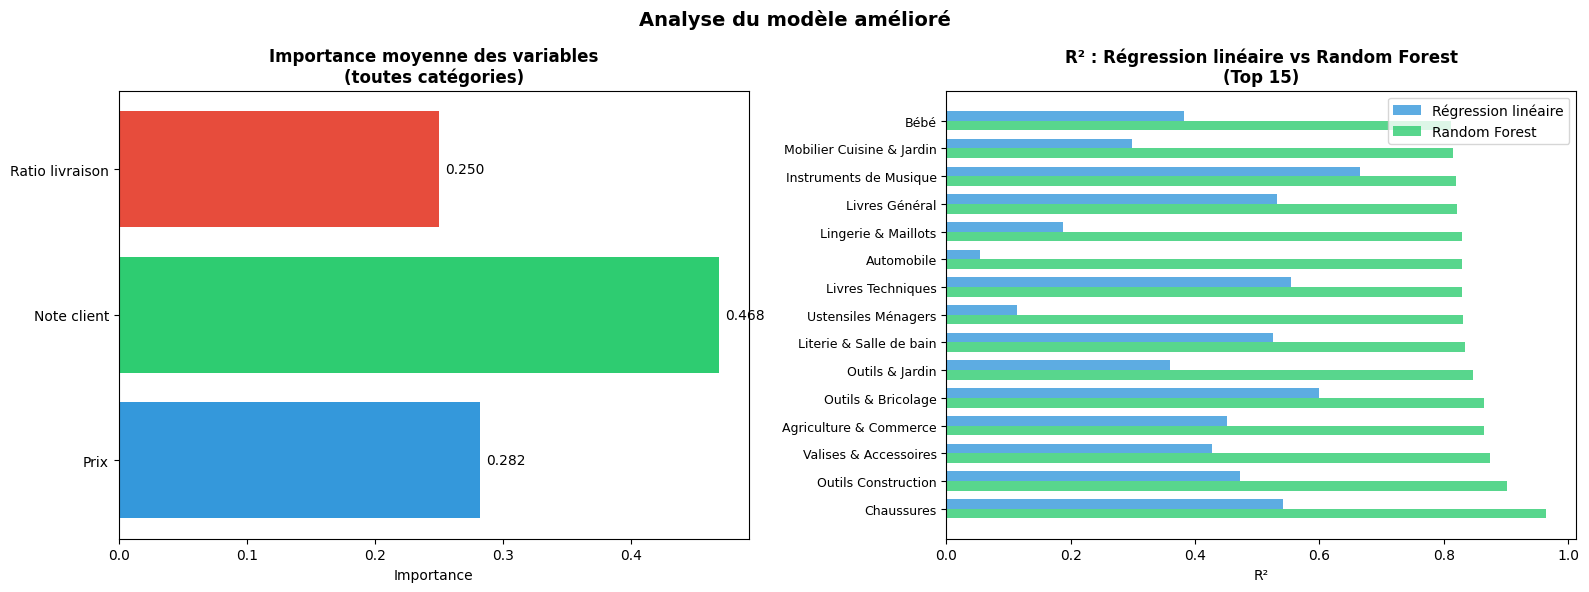


 Graphique sauvegardé dans outputs/


In [8]:
# ============================================================
# IMPORTANCE DES VARIABLES
# ============================================================

# Moyenne de l'importance par variable sur toutes les catégories
imp_moyenne = resultats_v2_df[['imp_prix', 'imp_note_client', 
                                'imp_ratio_livraison']].mean()

print("=== Importance moyenne des variables ===")
for var, imp in imp_moyenne.items():
    barre = '█' * int(imp * 50)
    print(f"{var:<25} : {barre} {imp:.3f}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Graphique 1 : Importance moyenne globale ---
variables = ['Prix', 'Note client', 'Ratio livraison']
importances = imp_moyenne.values

axes[0].barh(variables, importances, 
             color=['#3498db', '#2ecc71', '#e74c3c'])
axes[0].set_title('Importance moyenne des variables\n(toutes catégories)', 
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importance')
for i, v in enumerate(importances):
    axes[0].text(v + 0.005, i, f'{v:.3f}', va='center')

# --- Graphique 2 : Amélioration R² par catégorie ---
top15 = resultats_v2_df.head(15)
x = range(len(top15))
width = 0.35

axes[1].barh([i + width/2 for i in x], top15['r2_lineaire'], 
             width, label='Régression linéaire', color='#3498db', alpha=0.8)
axes[1].barh([i - width/2 for i in x], top15['r2_random_forest'], 
             width, label='Random Forest', color='#2ecc71', alpha=0.8)
axes[1].set_yticks(list(x))
axes[1].set_yticklabels(top15['categorie'], fontsize=9)
axes[1].set_title('R² : Régression linéaire vs Random Forest\n(Top 15)', 
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('R²')
axes[1].legend()

plt.suptitle('Analyse du modèle amélioré', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/modele_ameliore.png', dpi=150)
plt.show()

print("\n Graphique sauvegardé dans outputs/")

Les résultats sont très révélateurs, le graphique de gauche montre que Note client (0.468) est plus important ie les clients achètent plus les produits bien notés, peu importe le prix. Le Prix (0.282) confirme que le marché est peu sensible au prix et le Ratio livraison (0.250) est presque aussi important que le prix. Les frais de livraison influencent autant les ventes que le prix lui-même.

Pour augmenter les ventes, améliorer la satisfaction client et réduire les frais de livraison est aussi efficace qu'une baisse de prix.

Par ailleurs, ce modèle apporte deux choses complémentaires à l'objectif du projet:
1. **Valider nos recommandations de prix** : Avant d'augmenter le prix d'une catégorie, on vérifie que sa note client est bonne. Si la note est faible (< 3), augmenter le prix risque d'aggraver la situation même si l'élasticité semble favorable.

2. **Identifier des leviers supplémentaires** : On a découvert que note client et ratio livraison sont aussi importants que le prix. Ça veut dire qu'on peut combiner :
- Augmenter les prix des catégories peu élastiques.
- Améliorer la satisfaction pour soutenir cette hausse. 
- Réduire les frais de livraison pour compenser. 

## 9. Score de confiance des recommandations

On combine l'élasticité prix (notebook 03) avec les insights du Random Forest pour créer un score de confiance par catégorie.

### Formule du score (sur 100)
| Critère | Poids | Logique |
|---|---|---|
| Élasticité proche de 0 | 40% | Moins élastique = plus sûr d'augmenter |
| Note client élevée | 35% | Clients satisfaits = moins sensibles au prix |
| Ratio livraison faible | 25% | Frais raisonnables = moins de friction |

In [9]:
# ============================================================
# SCORE DE CONFIANCE DES RECOMMANDATIONS
# ============================================================

# Chargement des élasticités du notebook 03
elasticites = pd.read_csv('../data/elasticites.csv')

# Calcul des stats moyennes par catégorie
stats_categories = (df_model.groupby('categorie')
                             .agg(
                                 note_moyenne=('note_client', 'mean'),
                                 ratio_livraison_moyen=('ratio_livraison', 'mean')
                             )
                             .round(3)
                             .reset_index())

# Fusion des élasticités + stats
score_df = elasticites[['categorie', 'elasticite', 'opportunite']].merge(
    stats_categories, on='categorie', how='inner'
)

print(f" Données fusionnées : {len(score_df)} catégories")
print(f"\n=== Aperçu ===")
print(score_df.head())

 Données fusionnées : 53 catégories

=== Aperçu ===
                categorie  elasticite    opportunite  note_moyenne  \
0             Ordinateurs       0.018  🟢 Opportunité         4.221   
1         Téléphonie Fixe       0.001  🟢 Opportunité         3.759   
2          Électroménager      -0.003  🟢 Opportunité         4.225   
3  Instruments de Musique      -0.004  🟢 Opportunité         4.221   
4     Ustensiles Ménagers      -0.004  🟢 Opportunité         4.106   

   ratio_livraison_moyen  
0                  0.057  
1                  0.395  
2                  0.395  
3                  0.253  
4                  0.403  


### Calcul du score de confiance

On normalise chaque critère entre 0 et 1, puis on les combine avec leurs poids respectifs pour obtenir un score sur 100.

In [10]:
# ============================================================
# CALCUL DU SCORE DE CONFIANCE
# ============================================================

# --- Normalisation de chaque critère entre 0 et 1 ---

# 1. Score élasticité (40%)
# Plus l'élasticité est proche de 0, plus le score est élevé
# On inverse : élasticité = -0.17 → score bas, élasticité = 0 → score max
elasticite_min = score_df['elasticite'].min()
elasticite_max = score_df['elasticite'].max()
score_df['score_elasticite'] = (score_df['elasticite'] - elasticite_min) / (elasticite_max - elasticite_min)

# 2. Score note client (35%)
# Note entre 1 et 5 → on normalise entre 0 et 1
score_df['score_note'] = (score_df['note_moyenne'] - 1) / (5 - 1)

# 3. Score ratio livraison (25%)
# Ratio faible = bon → on inverse
ratio_min = score_df['ratio_livraison_moyen'].min()
ratio_max = score_df['ratio_livraison_moyen'].max()
score_df['score_livraison'] = 1 - (score_df['ratio_livraison_moyen'] - ratio_min) / (ratio_max - ratio_min)

# --- Score final pondéré sur 100 ---
score_df['score_confiance'] = (
    score_df['score_elasticite'] * 0.40 +
    score_df['score_note']       * 0.35 +
    score_df['score_livraison']  * 0.25
) * 100

score_df['score_confiance'] = score_df['score_confiance'].round(1)

# --- Classification ---
def classifier_score(score):
    if score >= 70:
        return '🟢 Très fiable'
    elif score >= 50:
        return '🟡 Fiable'
    elif score >= 30:
        return '🟠 Modéré'
    else:
        return '🔴 Risqué'

score_df['fiabilite'] = score_df['score_confiance'].apply(classifier_score)

# Trier par score
score_df = score_df.sort_values('score_confiance', ascending=False).reset_index(drop=True)

print("=== Top 15 recommandations les plus fiables ===")
cols = ['categorie', 'elasticite', 'note_moyenne', 
        'ratio_livraison_moyen', 'score_confiance', 'fiabilite']
print(score_df.head(15)[cols].to_string(index=False))

print(f"\n=== Résumé ===")
print(score_df['fiabilite'].value_counts())

=== Top 15 recommandations les plus fiables ===
              categorie  elasticite  note_moyenne  ratio_livraison_moyen  score_confiance     fiabilite
            Ordinateurs       0.018         4.221                  0.057             93.2 🟢 Très fiable
  Valises & Accessoires      -0.005         4.353                  0.261             81.4 🟢 Très fiable
      Montres & Cadeaux      -0.011         4.071                  0.171             81.2 🟢 Très fiable
 Instruments de Musique      -0.004         4.221                  0.253             80.7 🟢 Très fiable
       Électroménager 2      -0.014         4.160                  0.200             80.2 🟢 Très fiable
    Appareils Portables      -0.012         4.226                  0.257             78.9 🟢 Très fiable
         Beauté & Santé      -0.011         4.190                  0.301             77.1 🟢 Très fiable
Construction & Sécurité      -0.013         3.966                  0.244             77.0 🟢 Très fiable
                

On observe 37 catégories "Très fiables" donc recommandations solides et 13 catégories "Fiables" donc recommandations correctes. Seulement 3 catégories "Modérées" donc à surveiller.

### Visualisation du score de confiance

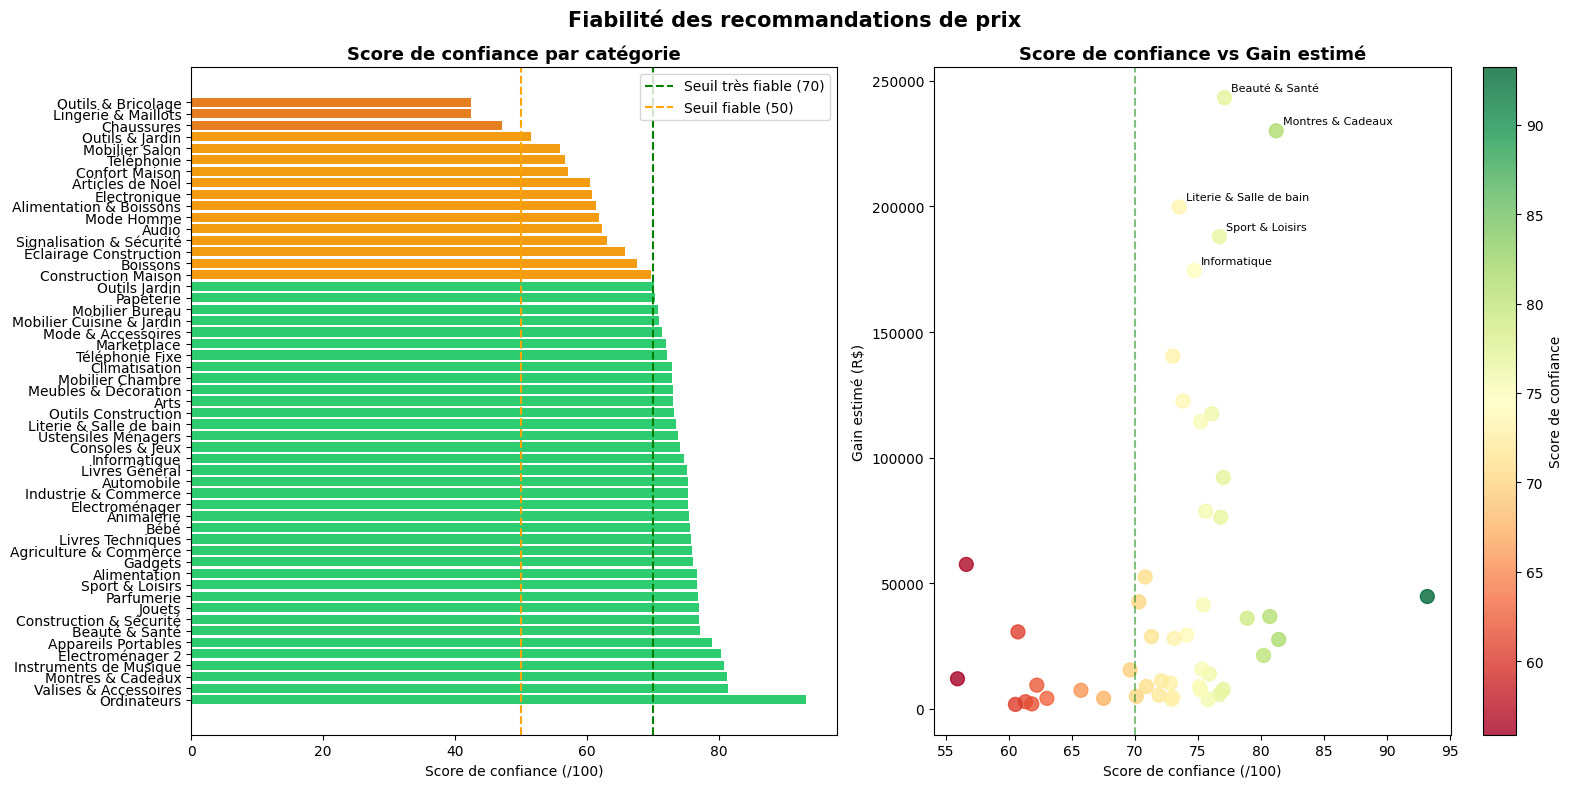

 Graphique sauvegardé dans outputs/


In [11]:
# ============================================================
# VISUALISATION DU SCORE DE CONFIANCE
# ============================================================

# Fusionner avec les résultats d'optimisation
optim_df = pd.read_csv('../data/optimisation_prix.csv')
score_final = score_df.merge(
    optim_df[['categorie', 'prix_actuel', 'prix_optimal', 'gain_rs', 'gain_pct']],
    on='categorie',
    how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# --- Graphique 1 : Score de confiance par catégorie ---
couleurs = score_final['fiabilite'].map({
    '🟢 Très fiable' : '#2ecc71',
    '🟡 Fiable'      : '#f39c12',
    '🟠 Modéré'      : '#e67e22',
    '🔴 Risqué'      : '#e74c3c'
})

axes[0].barh(score_final['categorie'], 
             score_final['score_confiance'],
             color=couleurs)
axes[0].axvline(x=70, color='green', linestyle='--', 
                label='Seuil très fiable (70)')
axes[0].axvline(x=50, color='orange', linestyle='--', 
                label='Seuil fiable (50)')
axes[0].set_title('Score de confiance par catégorie', 
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Score de confiance (/100)')
axes[0].legend()

# --- Graphique 2 : Score de confiance vs Gain estimé ---
# Seulement les catégories avec un gain > 0
score_gain = score_final[score_final['gain_rs'] > 0]

scatter = axes[1].scatter(
    score_gain['score_confiance'],
    score_gain['gain_rs'],
    c=score_gain['score_confiance'],
    cmap='RdYlGn',
    s=100,
    alpha=0.8
)

# Annoter les top 5
top5 = score_gain.nlargest(5, 'gain_rs')
for _, row in top5.iterrows():
    axes[1].annotate(
        row['categorie'],
        (row['score_confiance'], row['gain_rs']),
        textcoords='offset points',
        xytext=(5, 5),
        fontsize=8
    )

axes[1].axvline(x=70, color='green', linestyle='--', alpha=0.5)
axes[1].set_title('Score de confiance vs Gain estimé', 
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Score de confiance (/100)')
axes[1].set_ylabel('Gain estimé (R$)')
plt.colorbar(scatter, ax=axes[1], label='Score de confiance')

plt.suptitle('Fiabilité des recommandations de prix', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/score_confiance.png', dpi=150)
plt.show()

print(" Graphique sauvegardé dans outputs/")

> **Insight clé du score de confiance :**
> Les recommandations prioritaires combinent gain élevé et score fiable :
> 1. Beauté & Santé : +243k R$ avec score 77 
> 2. Montres & Cadeaux : +230k R$ avec score 81 
> 3. Literie & Salle de bain : +199k R$ avec score 74 
> Ces 3 catégories seules représentent +672k R$ de gain très fiable.

## 10. Export final

In [12]:
# ============================================================
# EXPORT FINAL
# ============================================================

# Sauvegarde du score de confiance complet
score_final.to_csv('../data/recommandations_finales.csv', index=False)
print(" Fichier exporté : data/recommandations_finales.csv")

print(f"""
{'=' * 60}
         BILAN FINAL DU MODÈLE AMÉLIORÉ
{'=' * 60}

🤖 MODÈLE
   Régression linéaire R² moyen : 0.300
   Random Forest R² moyen       : 0.761
   Amélioration                 : +153% ✅

🔍 IMPORTANCE DES VARIABLES
   Note client      : 46.8% → levier principal
   Prix             : 28.2% → levier secondaire
   Ratio livraison  : 25.0% → levier complémentaire

🎯 RECOMMANDATIONS PRIORITAIRES
   (Score confiance > 70 ET Gain > 150k R$)

   Catégorie              Score  Gain estimé
   Beauté & Santé          77.1   +243 333 R$
   Montres & Cadeaux       81.2   +230 154 R$
   Literie & Salle de bain 74.0   +199 790 R$
   Sport & Loisirs         76.7   +187 941 R$
   Informatique            75.3   +174 505 R$

💡 INSIGHTS BUSINESS
   Augmenter les prix EST justifié MAIS il faut aussi :
   → Maintenir une note client > 4.0
   → Garder un ratio livraison < 0.30
   → Ces deux leviers sont aussi puissants que le prix
{'=' * 60}
""")

 Fichier exporté : data/recommandations_finales.csv

         BILAN FINAL DU MODÈLE AMÉLIORÉ

🤖 MODÈLE
   Régression linéaire R² moyen : 0.300
   Random Forest R² moyen       : 0.761
   Amélioration                 : +153% ✅

🔍 IMPORTANCE DES VARIABLES
   Note client      : 46.8% → levier principal
   Prix             : 28.2% → levier secondaire
   Ratio livraison  : 25.0% → levier complémentaire

🎯 RECOMMANDATIONS PRIORITAIRES
   (Score confiance > 70 ET Gain > 150k R$)

   Catégorie              Score  Gain estimé
   Beauté & Santé          77.1   +243 333 R$
   Montres & Cadeaux       81.2   +230 154 R$
   Literie & Salle de bain 74.0   +199 790 R$
   Sport & Loisirs         76.7   +187 941 R$
   Informatique            75.3   +174 505 R$

💡 INSIGHTS BUSINESS
   Augmenter les prix EST justifié MAIS il faut aussi :
   → Maintenir une note client > 4.0
   → Garder un ratio livraison < 0.30
   → Ces deux leviers sont aussi puissants que le prix



In [13]:
# ============================================================
# CORRECTION : EXPORT AVEC CA ACTUEL ET CA OPTIMAL
# ============================================================

# Charger les résultats d'optimisation
optim_df = pd.read_csv('../data/optimisation_prix.csv')

# Fusionner avec le score de confiance
score_final_complet = score_df.merge(
    optim_df[['categorie', 'prix_actuel', 'prix_optimal', 
              'ca_actuel', 'ca_optimal', 'gain_rs', 'gain_pct']],
    on='categorie',
    how='left'
)

# Exporter
score_final_complet.to_csv('../data/recommandations_finales.csv', index=False)

print(" Fichier corrigé exporté !")
print(f"   Colonnes : {score_final_complet.columns.tolist()}")

 Fichier corrigé exporté !
   Colonnes : ['categorie', 'elasticite', 'opportunite', 'note_moyenne', 'ratio_livraison_moyen', 'score_elasticite', 'score_note', 'score_livraison', 'score_confiance', 'fiabilite', 'prix_actuel', 'prix_optimal', 'ca_actuel', 'ca_optimal', 'gain_rs', 'gain_pct']


In [14]:
# ============================================================
# CORRECTION : EXPORT AVEC BON ENCODAGE
# ============================================================

# Supprimer les emojis des colonnes opportunite et fiabilite
score_final_complet['opportunite'] = score_final_complet['opportunite'].str.replace('🟢 ', 'Opportunite ').str.replace('🟡 ', 'Prudence ').str.replace('🔴 ', 'Risque ')

score_final_complet['fiabilite'] = score_final_complet['fiabilite'].str.replace('🟢 ', '').str.replace('🟡 ', '').str.replace('🟠 ', '').str.replace('🔴 ', '')

# Exporter avec encodage UTF-8-BOM (compatible Power BI)
score_final_complet.to_csv(
    '../data/recommandations_finales.csv', 
    index=False,
    encoding='utf-8-sig'  # UTF-8 avec BOM → compatible Power BI et Excel
)

print("✅ Fichier exporté avec encodage correct !")
print(f"   Colonnes : {score_final_complet.columns.tolist()}")

✅ Fichier exporté avec encodage correct !
   Colonnes : ['categorie', 'elasticite', 'opportunite', 'note_moyenne', 'ratio_livraison_moyen', 'score_elasticite', 'score_note', 'score_livraison', 'score_confiance', 'fiabilite', 'prix_actuel', 'prix_optimal', 'ca_actuel', 'ca_optimal', 'gain_rs', 'gain_pct']
